Using device: cuda


C:\Users\Ratan Maurya\AppData\Local\Temp\ipykernel_14996\3786695674.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("unet_disaster_model(100).pth", map_loca

✅ Model loaded successfully!


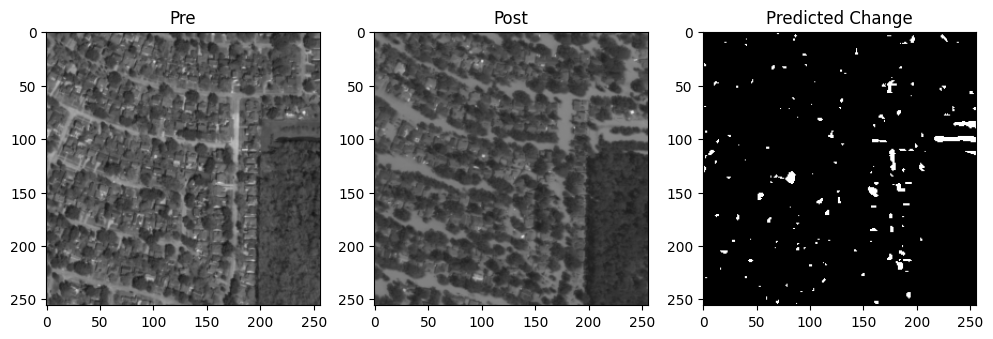

Damage %: 2.48


In [17]:
# ===================== 1. IMPORTS =====================
import torch
import torch.nn as nn
import os
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt

# ===================== 2. DEVICE =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===================== 3. UNET MODEL =====================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=6, out_channels=1):
        super().__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        d3 = self.down3(self.pool2(d2))
        d4 = self.down4(self.pool3(d3))

        bottleneck = self.bottleneck(self.pool4(d4))

        u4 = self.up4(bottleneck)
        u4 = torch.cat([u4, d4], dim=1)
        u4 = self.conv4(u4)

        u3 = self.up3(u4)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.final(u1)

# ===================== 4. DATASET =====================
class DisasterDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir):
        self.pre_path = os.path.join(root_dir, "pre")
        self.post_path = os.path.join(root_dir, "post")
        self.images = os.listdir(self.pre_path)

        self.transform = T.Compose([
            T.Resize((256, 256)),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        pre = Image.open(os.path.join(self.pre_path, img_name)).convert("RGB")
        post = Image.open(os.path.join(self.post_path, img_name)).convert("RGB")

        pre = self.transform(pre)
        post = self.transform(post)

        return pre, post

# ===================== 5. LOAD MODEL =====================
model = UNet(in_channels=6, out_channels=1)

model.load_state_dict(
    torch.load("unet_disaster_model(100).pth", map_location=device)
)

model = model.to(device)
model.eval()

print("✅ Model loaded successfully!")

# ===================== 6. LOAD DATA =====================
dataset = DisasterDataset(r"I:\Dataset(new)\selected_100")

pre, post = dataset[30]

# ===================== 7. INFERENCE =====================
pre_t = pre.unsqueeze(0).to(device)
post_t = post.unsqueeze(0).to(device)

inp = torch.cat((pre_t, post_t), dim=1)

with torch.no_grad():
    output = torch.sigmoid(model(inp))

mask = (output > 0.5).float()

# ===================== 8. VISUALIZATION =====================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Pre")
plt.imshow(pre.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Post")
plt.imshow(post.permute(1,2,0))

plt.subplot(1,3,3)
plt.title("Predicted Change")
plt.imshow(mask.squeeze().cpu(), cmap='gray')

plt.show()

# ===================== 9. DAMAGE ANALYSIS =====================
total_pixels = mask.numel()
changed_pixels = mask.sum().item()

damage_percentage = (changed_pixels / total_pixels) * 100

print("Damage %:", round(damage_percentage, 2))

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def create_heatmap_overlay_no_cv2(pre, mask):
    
    # Convert tensor → numpy
    pre_img = pre.squeeze().permute(1, 2, 0).cpu().numpy()
    mask_np = mask.squeeze().cpu().numpy()

    # Normalize mask
    mask_np = (mask_np - mask_np.min()) / (mask_np.max() + 1e-8)

    # Create heatmap using matplotlib colormap
    heatmap = plt.cm.jet(mask_np)[:, :, :3]  # remove alpha

    # Overlay
    overlay = 0.7 * pre_img + 0.3 * heatmap

    return heatmap, overlay

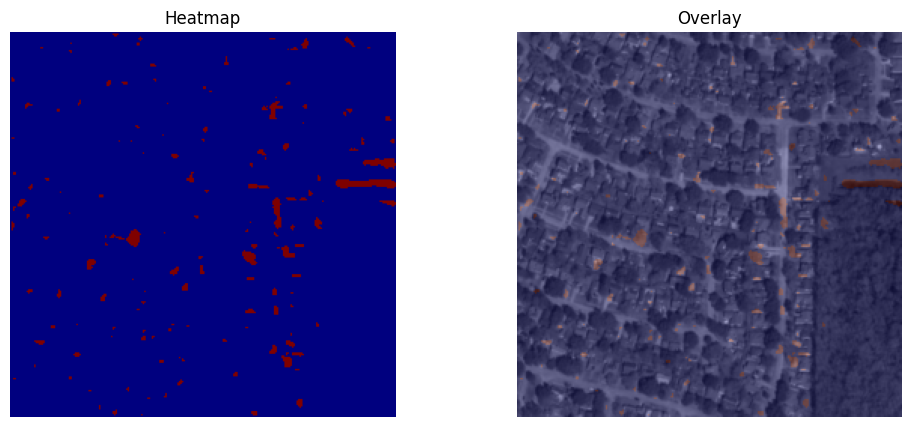

In [20]:
heatmap, overlay = create_heatmap_overlay_no_cv2(pre, mask)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Heatmap")
plt.imshow(heatmap)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.show()